In [143]:
import pandas as pd
import matplotlib.pyplot as plt  # we will use this for plotting
import matplotlib.ticker as ticker
from datetime import datetime, timezone

df = pd.read_csv("cristiano_youtube_stats.csv")


df['pull_date'] = pd.to_datetime(df['pull_date'])
df['publishTime'] = pd.to_datetime(df['publishTime'])
df

C:\Users\AD\AppData\Local\Temp\ipykernel_9980\1873299905.py:6: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cristiano_youtube_stats.csv")


,id,title,description,publishTime,kind_stats,duration_seconds,video_type,viewCount,likeCount,commentCount,...,thumbnails.medium.url,thumbnails.high.url,contentDetails.duration,contentDetails.dimension,topicDetails.topicCategories,snippet.defaultLanguage,localizations.en.title,localizations.en.description,snippet.tags,pull_date
0,-nwzc7plJQw,Cristiano Ronaldo REACTS to ALL his 14 GOALS i...,All Cristiano Ronaldo’s 14 UEFA European Champ...,2024-09-23 13:00:00+00:00,youtube#video,546,long,4698386,396780,17978,...,https://i.ytimg.com/vi/-nwzc7plJQw/mqdefault.jpg,https://i.ytimg.com/vi/-nwzc7plJQw/hqdefault.jpg,PT9M6S,2d,['https://en.wikipedia.org/wiki/Association_fo...,NaN,NaN,NaN,NaN,2025-02-16
1,-vwNPsvZ0Sc,¡Cristiano Ronaldo te da la bienvenida a UR Cr...,#Cristiano #URCristiano #CR7,2024-08-21 13:11:26+00:00,youtube#video,60,long,11207233,1895059,40000,...,https://i.ytimg.com/vi/-vwNPsvZ0Sc/mqdefault.jpg,https://i.ytimg.com/vi/-vwNPsvZ0Sc/hqdefault.jpg,PT1M,2d,['https://en.wikipedia.org/wiki/Association_fo...,NaN,Cristiano Ronaldo welcomes you to UR Cristiano!,#Cristiano #URCristiano #CR7,NaN,2025-02-16
2,0kaEMM58_AY,Las 5 cosas que NO SABÍAS sobre Cristiano Rona...,El reto más divertido entre Georgina Rodríguez...,2024-09-09 13:42:17+00:00,youtube#video,879,long,5952588,571309,22927,...,https://i.ytimg.com/vi/0kaEMM58_AY/mqdefault.jpg,https://i.ytimg.com/vi/0kaEMM58_AY/hqdefault.jpg,PT14M39S,2d,['https://en.wikipedia.org/wiki/Entertainment'],NaN,The 5 things you DIDN'T KNOW about Cristiano R...,The funniest challenge with Georgina and Crist...,NaN,2025-02-16
3,1ddy3O1Ma4U,The Ultimate Christmas Surprise for Cristiano’...,Christmas is coming and nothing better for Cri...,2024-12-16 14:00:06+00:00,youtube#video,179,long,4595510,290000,10435,...,https://i.ytimg.com/vi/1ddy3O1Ma4U/mqdefault.jpg,https://i.ytimg.com/vi/1ddy3O1Ma4U/hqdefault.jpg,PT2M59S,2d,['https://en.wikipedia.org/wiki/Sport'],NaN,NaN,NaN,NaN,2025-02-16
4,1h-zdPlWu4Y,TOMORROW: Full ITW of Cristiano with Edu. Excl...,NaN,2025-02-16 18:47:02+00:00,youtube#video,57,short,37060,6633,396,...,https://i.ytimg.com/vi/1h-zdPlWu4Y/mqdefault.jpg,https://i.ytimg.com/vi/1h-zdPlWu4Y/hqdefault.jpg,PT57S,2d,['https://en.wikipedia.org/wiki/Lifestyle_(soc...,NaN,NaN,NaN,NaN,2025-02-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57570,xm6RYCn5GK4,The Next Era Of Wellness: PRO2COL,This is a new chapter for me and @Herbalife. \...,2026-02-19 22:34:42+00:00,youtube#video,16,short,4461391,182579,15568,...,https://i.ytimg.com/vi/xm6RYCn5GK4/mqdefault.jpg,https://i.ytimg.com/vi/xm6RYCn5GK4/hqdefault.jpg,PT16S,2d,['https://en.wikipedia.org/wiki/Health'],en,The Next Era Of Wellness: PRO2COL,This is a new chapter for me and @Herbalife. \...,NaN,2026-10-04
57571,yBhSMQWFOFw,"Cristiano shoots, MrBeast tries to stop it... ...",NaN,2025-01-03 13:57:57+00:00,youtube#video,24,short,8688845,419004,18850,...,https://i.ytimg.com/vi/yBhSMQWFOFw/mqdefault.jpg,https://i.ytimg.com/vi/yBhSMQWFOFw/hqdefault.jpg,PT24S,2d,['https://en.wikipedia.org/wiki/Association_fo...,en,"Cristiano shoots, MrBeast tries to stop it... ...",NaN,NaN,2026-10-04
57572,yxQPyHMkl2E,Now it's your time to Rise Above!,"In every era, a rare few rise above the rest. ...",2025-07-01 17:46:53+00:00,youtube#video,30,short,3330094,175240,7669,...,https://i.ytimg.com/vi/yxQPyHMkl2E/mqdefault.jpg,https://i.ytimg.com/vi/yxQPyHMkl2E/hqdefault.jpg,PT30S,2d,['https://en.wikipedia.org/wiki/Video_game_cul...,en,Now it's your time to Rise Above!,"In every era, a rare few rise above the rest. ...",NaN,2026-10-04
57573,z-ZHtSfWiMw,Cristiano Ronaldo and his kids dance with Sant...,Watch the full Santa Claus trip on the channel!,2024-12-30 14:04:31+00:00,youtube#video,26,short,4556110,307649,8792,...,https://i.ytimg.com/vi/z-ZHtSfWiMw/mqdefault.jpg,https://i.ytimg.com/vi/z-ZHtSfWiMw/hqdefault.jpg,PT26S,2d,"['https://en.wikipedia.org/wiki/Hobby', 'https...",es,NaN,NaN,NaN,2026-10-04


In [144]:
#TOP 5 MOST VIEWED VIDEOS FROM CR7
df_copy = df.copy()

df_copy = df_copy.loc[df_copy.groupby('id')['viewCount'].idxmax()]
df_copy = df_copy.sort_values('viewCount', ascending= False)

#Only Long Form videos
df_copy = df_copy[df_copy['video_type'] == 'long']
df_copy

,id,title,description,publishTime,kind_stats,duration_seconds,video_type,viewCount,likeCount,commentCount,...,thumbnails.medium.url,thumbnails.high.url,contentDetails.duration,contentDetails.dimension,topicDetails.topicCategories,snippet.defaultLanguage,localizations.en.title,localizations.en.description,snippet.tags,pull_date
57520,aDF_ESN80r8,I Meet MrBeast To Break The Internet!!,Cristiano Ronaldo meets the biggest Youtuber a...,2024-11-21 14:00:07+00:00,youtube#video,840,long,69804744,5183687,186434,...,https://i.ytimg.com/vi/aDF_ESN80r8/mqdefault.jpg,https://i.ytimg.com/vi/aDF_ESN80r8/hqdefault.jpg,PT14M,2d,['https://en.wikipedia.org/wiki/Association_fo...,en,I Meet MrBeast To Break The Internet!!,Cristiano Ronaldo meets the biggest Youtuber a...,NaN,2026-10-04
57494,PbgUg_aBHf4,The golden button… for my golden kids,Cristiano shares with his family his happiness...,2024-08-21 21:54:33+00:00,youtube#video,107,long,56100966,4419796,234235,...,https://i.ytimg.com/vi/PbgUg_aBHf4/mqdefault.jpg,https://i.ytimg.com/vi/PbgUg_aBHf4/hqdefault.jpg,PT1M47S,2d,['https://en.wikipedia.org/wiki/Lifestyle_(soc...,en,The golden button… for my golden kids,Cristiano shares with his family his happiness...,NaN,2026-10-04
57482,I74FAkaL1Fk,Cristiano Ronaldo y Georgina revelan todo en e...,Cristiano y Georgina revelan sus intimidades m...,2024-08-21 13:12:46+00:00,youtube#video,176,long,47440750,3726269,194887,...,https://i.ytimg.com/vi/I74FAkaL1Fk/mqdefault.jpg,https://i.ytimg.com/vi/I74FAkaL1Fk/hqdefault.jpg,PT2M56S,2d,['https://en.wikipedia.org/wiki/Entertainment'],es,Cristiano Ronaldo y Georgina REVEAL ALL in the...,Cristiano and Georgina reveal their most fun s...,NaN,2026-10-04
57543,jeDKsg8r3ew,When I met the most famous Cristiano,Discover the shocking moment when Cristiano di...,2024-08-21 13:00:06+00:00,youtube#video,63,long,38217162,2821913,119289,...,https://i.ytimg.com/vi/jeDKsg8r3ew/mqdefault.jpg,https://i.ytimg.com/vi/jeDKsg8r3ew/hqdefault.jpg,PT1M3S,2d,['https://en.wikipedia.org/wiki/Association_fo...,en,When I met the most famous Cristiano,Discover the shocking moment when Cristiano di...,NaN,2026-10-04
57518,_ZsZ4-HyjCg,I face off with MrBeast,Cristiano and Jimmy engage in a high-stakes ch...,2024-11-30 17:00:06+00:00,youtube#video,746,long,36957441,2381394,67887,...,https://i.ytimg.com/vi/_ZsZ4-HyjCg/mqdefault.jpg,https://i.ytimg.com/vi/_ZsZ4-HyjCg/hqdefault.jpg,PT12M26S,2d,['https://en.wikipedia.org/wiki/Association_fo...,en,I face off with MrBeast,Cristiano and Jimmy engage in a high-stakes ch...,NaN,2026-10-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57458,ARzb2K2FFwk,Live: FIP Silver Lisboa Racket Centre 2025 finals,"Welcome to the livestream of the FIP Silver, h...",2025-09-21 19:41:41+00:00,youtube#video,12383,long,640103,28313,719,...,https://i.ytimg.com/vi/ARzb2K2FFwk/mqdefault.jpg,https://i.ytimg.com/vi/ARzb2K2FFwk/hqdefault.jpg,PT3H26M23S,2d,"['https://en.wikipedia.org/wiki/Sport', 'https...",en,Live: FIP Silver Lisboa Racket Centre 2025 finals,"Welcome to the livestream of the FIP Silver, h...",NaN,2026-10-04
57551,obajORA0ICM,Cristiano Takes the MMA Show To Lisbon in a WO...,"Tomorrow night, Lisbon becomes the center of t...",2026-05-21 12:08:18+00:00,youtube#video,625,long,377166,21639,1836,...,https://i.ytimg.com/vi/obajORA0ICM/mqdefault.jpg,https://i.ytimg.com/vi/obajORA0ICM/hqdefault.jpg,PT10M25S,2d,['https://en.wikipedia.org/wiki/Mixed_martial_...,en,Cristiano Takes the MMA Show To Lisbon in a WO...,"Tomorrow night, Lisbon becomes the center of t...",NaN,2026-10-04
57432,2V3s_d3MCE4,Live: FIP Silver Lisboa Racket Centre 2025 Sem...,"Welcome to the livestream of the FIP Silver, h...",2025-09-21 16:24:41+00:00,youtube#video,27411,long,330153,22978,158,...,https://i.ytimg.com/vi/2V3s_d3MCE4/mqdefault.jpg,https://i.ytimg.com/vi/2V3s_d3MCE4/hqdefault.jpg,PT7H36M51S,2d,"['https://en.wikipedia.org/wiki/Sport', 'https...",en,Live: FIP Silver Lisboa Racket Centre 2025 Sem.

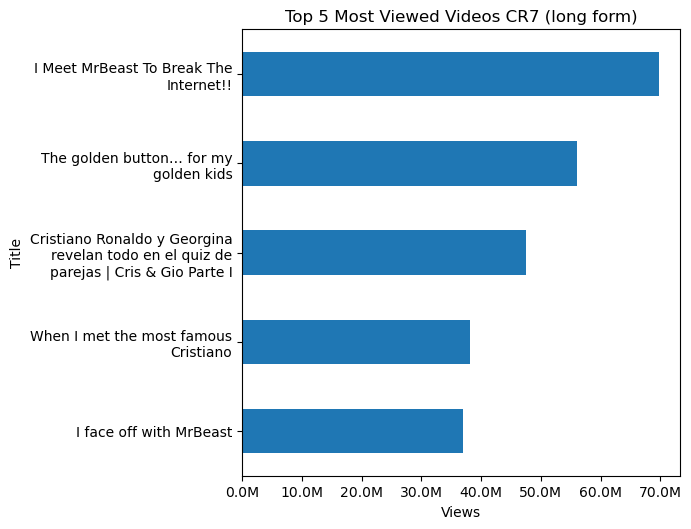

In [145]:
import textwrap

ax = df_copy.head().sort_values('viewCount', ascending= True).plot.barh(y= 'viewCount', x= 'title', figsize= (7,5), legend= False)
top = df_copy.head().sort_values('viewCount', ascending= True)
def millions_formatter(x, pos):
    return f'{x*1e-6:.1f}M'

#Set the ytickslabels as df_copy.head() with wrapping
ax.set_yticklabels([textwrap.fill(t, width=30) for t in top['title']])
ax.xaxis.set_major_formatter(ticker.FuncFormatter(millions_formatter))

plt.tight_layout()
plt.ylabel('Title')
plt.xlabel('Views')
plt.title('Top 5 Most Viewed Videos CR7 (long form)')
plt.show()



In [146]:
df_copy2 = df.copy()
df_copy2 = df_copy2.loc[df_copy2.groupby('id')['viewCount'].idxmax()]
df_copy2.sort_values('viewCount', ascending=False)

df_copy3 = df[df['id'] == 'OTjaZwoFvBA']
df_copy3

,id,title,description,publishTime,kind_stats,duration_seconds,video_type,viewCount,likeCount,commentCount,...,thumbnails.medium.url,thumbnails.high.url,contentDetails.duration,contentDetails.dimension,topicDetails.topicCategories,snippet.defaultLanguage,localizations.en.title,localizations.en.description,snippet.tags,pull_date
46940,OTjaZwoFvBA,One team; one dream 🇵🇹,Next Stop: Miami. \nLet's go Portugal! 🇵🇹\n\n...,2026-06-17 13:57:39+00:00,youtube#video,35,short,754115,58361,3058,...,https://i.ytimg.com/vi/OTjaZwoFvBA/mqdefault.jpg,https://i.ytimg.com/vi/OTjaZwoFvBA/hqdefault.jpg,PT35S,2d,['https://en.wikipedia.org/wiki/Lifestyle_(soc...,es,NaN,NaN,NaN,2026-06-18
47040,OTjaZwoFvBA,One team; one dream 🇵🇹,Next Stop: Miami. \nLet's go Portugal! 🇵🇹\n\n...,2026-06-17 13:57:39+00:00,youtube#video,35,short,1092004,74040,3918,...,https://i.ytimg.com/vi/OTjaZwoFvBA/mqdefault.jpg,https://i.ytimg.com/vi/OTjaZwoFvBA/hqdefault.jpg,PT35S,2d,['https://en.wikipedia.org/wiki/Lifestyle_(soc...,es,NaN,NaN,NaN,2026-06-19
47140,OTjaZwoFvBA,One team; one dream 🇵🇹,Next Stop: Miami. \nLet's go Portugal! 🇵🇹\n\n...,2026-06-17 13:57:39+00:00,youtube#video,35,short,1373287,86853,4572,...,https://i.ytimg.com/vi/OTjaZwoFvBA/mqdefault.jpg,https://i.ytimg.com/vi/OTjaZwoFvBA/hqdefault.jpg,PT35S,2d,['https://en.wikipedia.org/wiki/Lifestyle_(soc...,es,NaN,NaN,NaN,2026-06-20
47240,OTjaZwoFvBA,One team; one dream 🇵🇹,Next Stop: Miami. \nLet's go Portugal! 🇵🇹\n\n...,2026-06-17 13:57:39+00:00,youtube#video,35,short,1751107,97131,5127,...,https://i.ytimg.com/vi/OTjaZwoFvBA/mqdefault.jpg,https://i.ytimg.com/vi/OTjaZwoFvBA/hqdefault.jpg,PT35S,2d,['https://en.wikipedia.org/wiki/Lifestyle_(soc...,es,NaN,NaN,NaN,2026-06-21
47340,OTjaZwoFvBA,One team; one dream 🇵🇹,Next Stop: Miami. \nLet's go Portugal! 🇵🇹\n\n...,2026-06-17 13:57:39+00:00,youtube#video,35,short,2023433,105285,5517,...,https://i.ytimg.com/vi/OTjaZwoFvBA/mqdefault.jpg,https://i.ytimg.com/vi/OTjaZwoFvBA/hqdefault.jpg,PT35S,2d,['https://en.wikipedia.org/wiki/Lifestyle_(soc...,es,NaN,NaN,NaN,2026-06-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56971,OTjaZwoFvBA,One team; one dream 🇵🇹,Next Stop: Miami. \nLet's go Portugal! 🇵🇹\n\n...,2026-06-17 13:57:39+00:00,youtube#video,35,short,255104574,1330522,29396,...,https://i.ytimg.com/vi/OTjaZwoFvBA/mqdefault.jpg,https://i.ytimg.com/vi/OTjaZwoFvBA/hqdefault.jpg,PT35S,2d,['https://en.wikipedia.org/wiki/Lifestyle_(soc...,es,NaN,NaN,NaN,2026-09-30
57071,OTjaZwoFvBA,One team; one dream 🇵🇹,Next Stop: Miami. \nLet's go Portugal! 🇵🇹\n\n...,2026-06-17 13:57:39+00:00,youtube#video,35,short,255114762,1330918,29401,...,https://i.ytimg.com/vi/OTjaZwoFvBA/mqdefault.jpg,https://i.ytimg.com/vi/OTjaZwoFvBA/hqdefault.jpg,PT35S,2d,['https://en.wikipedia.org/wiki/Lifestyle_(soc...,es,NaN,NaN,NaN,2026-10-01
57192,OTjaZwoFvBA,One team; one dream 🇵🇹,Next Stop: Miami. \nLet's go Portugal! 🇵🇹\n\n...,2026-06-17 13:57:39+00:00,youtube#video,35,short,255141393,1332329,29454,...,https://i.ytimg.com/vi/OTjaZwoFvBA/mqdefault.jpg,https://i.ytimg.com/vi/OTjaZwoFvBA/hqdefault.jpg,PT35S,2d,['https://en.wikipedia.org/wiki/Lifestyle_(soc...,es,NaN,NaN,NaN,2026-10-02
57342,OTjaZwoFvBA,One team; one dream 🇵🇹,Next Stop: Miami. \nLet's go Portugal! 🇵🇹\n\n...,2026-06-17 13:57:39+00:00,youtube#video,35,short,255161535,1333357,29477,...,https://i.ytimg.com/vi/OTjaZwoFvBA/mqdefault.jpg,https://i.ytimg.com/vi/OTjaZwoFvBA/hqdefault.jpg,PT35S,2d,['https://en.wikipedia.org/wiki/Lifestyle_(soc...,es,NaN,NaN,NaN,2026-10-03


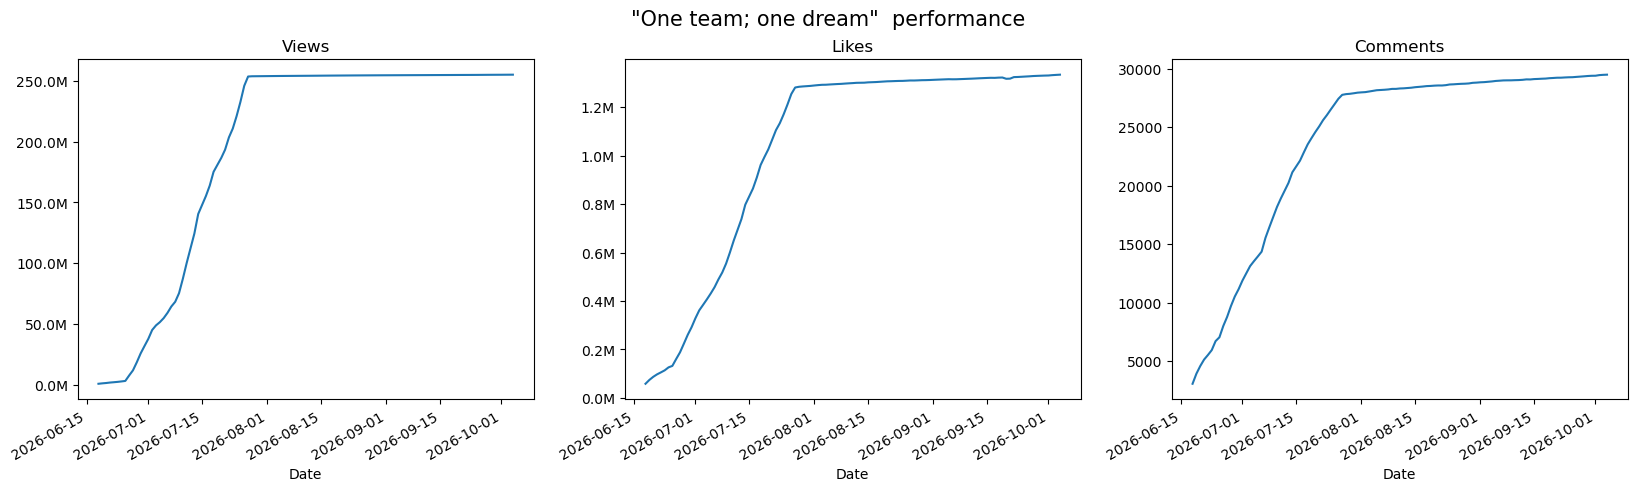

In [147]:
fig, ax = plt.subplots(1, 3)

l = ['viewCount', 'likeCount', 'commentCount']
title = ['Views', 'Likes', 'Comments']
for i, s in enumerate(l):
    df_copy3.plot.line(x= 'pull_date', y= s, ax= ax[i], figsize= (20, 5), title= title[i], legend= False)
    ax[i].set_xlabel('Date')


for i,s in enumerate(l[:2]):
    ax[i].yaxis.set_major_formatter(ticker.FuncFormatter(millions_formatter))


plt.suptitle('"One team; one dream"  performance', fontsize= 15)
plt.show()


In [148]:
df

,id,title,description,publishTime,kind_stats,duration_seconds,video_type,viewCount,likeCount,commentCount,...,thumbnails.medium.url,thumbnails.high.url,contentDetails.duration,contentDetails.dimension,topicDetails.topicCategories,snippet.defaultLanguage,localizations.en.title,localizations.en.description,snippet.tags,pull_date
0,-nwzc7plJQw,Cristiano Ronaldo REACTS to ALL his 14 GOALS i...,All Cristiano Ronaldo’s 14 UEFA European Champ...,2024-09-23 13:00:00+00:00,youtube#video,546,long,4698386,396780,17978,...,https://i.ytimg.com/vi/-nwzc7plJQw/mqdefault.jpg,https://i.ytimg.com/vi/-nwzc7plJQw/hqdefault.jpg,PT9M6S,2d,['https://en.wikipedia.org/wiki/Association_fo...,NaN,NaN,NaN,NaN,2025-02-16
1,-vwNPsvZ0Sc,¡Cristiano Ronaldo te da la bienvenida a UR Cr...,#Cristiano #URCristiano #CR7,2024-08-21 13:11:26+00:00,youtube#video,60,long,11207233,1895059,40000,...,https://i.ytimg.com/vi/-vwNPsvZ0Sc/mqdefault.jpg,https://i.ytimg.com/vi/-vwNPsvZ0Sc/hqdefault.jpg,PT1M,2d,['https://en.wikipedia.org/wiki/Association_fo...,NaN,Cristiano Ronaldo welcomes you to UR Cristiano!,#Cristiano #URCristiano #CR7,NaN,2025-02-16
2,0kaEMM58_AY,Las 5 cosas que NO SABÍAS sobre Cristiano Rona...,El reto más divertido entre Georgina Rodríguez...,2024-09-09 13:42:17+00:00,youtube#video,879,long,5952588,571309,22927,...,https://i.ytimg.com/vi/0kaEMM58_AY/mqdefault.jpg,https://i.ytimg.com/vi/0kaEMM58_AY/hqdefault.jpg,PT14M39S,2d,['https://en.wikipedia.org/wiki/Entertainment'],NaN,The 5 things you DIDN'T KNOW about Cristiano R...,The funniest challenge with Georgina and Crist...,NaN,2025-02-16
3,1ddy3O1Ma4U,The Ultimate Christmas Surprise for Cristiano’...,Christmas is coming and nothing better for Cri...,2024-12-16 14:00:06+00:00,youtube#video,179,long,4595510,290000,10435,...,https://i.ytimg.com/vi/1ddy3O1Ma4U/mqdefault.jpg,https://i.ytimg.com/vi/1ddy3O1Ma4U/hqdefault.jpg,PT2M59S,2d,['https://en.wikipedia.org/wiki/Sport'],NaN,NaN,NaN,NaN,2025-02-16
4,1h-zdPlWu4Y,TOMORROW: Full ITW of Cristiano with Edu. Excl...,NaN,2025-02-16 18:47:02+00:00,youtube#video,57,short,37060,6633,396,...,https://i.ytimg.com/vi/1h-zdPlWu4Y/mqdefault.jpg,https://i.ytimg.com/vi/1h-zdPlWu4Y/hqdefault.jpg,PT57S,2d,['https://en.wikipedia.org/wiki/Lifestyle_(soc...,NaN,NaN,NaN,NaN,2025-02-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57570,xm6RYCn5GK4,The Next Era Of Wellness: PRO2COL,This is a new chapter for me and @Herbalife. \...,2026-02-19 22:34:42+00:00,youtube#video,16,short,4461391,182579,15568,...,https://i.ytimg.com/vi/xm6RYCn5GK4/mqdefault.jpg,https://i.ytimg.com/vi/xm6RYCn5GK4/hqdefault.jpg,PT16S,2d,['https://en.wikipedia.org/wiki/Health'],en,The Next Era Of Wellness: PRO2COL,This is a new chapter for me and @Herbalife. \...,NaN,2026-10-04
57571,yBhSMQWFOFw,"Cristiano shoots, MrBeast tries to stop it... ...",NaN,2025-01-03 13:57:57+00:00,youtube#video,24,short,8688845,419004,18850,...,https://i.ytimg.com/vi/yBhSMQWFOFw/mqdefault.jpg,https://i.ytimg.com/vi/yBhSMQWFOFw/hqdefault.jpg,PT24S,2d,['https://en.wikipedia.org/wiki/Association_fo...,en,"Cristiano shoots, MrBeast tries to stop it... ...",NaN,NaN,2026-10-04
57572,yxQPyHMkl2E,Now it's your time to Rise Above!,"In every era, a rare few rise above the rest. ...",2025-07-01 17:46:53+00:00,youtube#video,30,short,3330094,175240,7669,...,https://i.ytimg.com/vi/yxQPyHMkl2E/mqdefault.jpg,https://i.ytimg.com/vi/yxQPyHMkl2E/hqdefault.jpg,PT30S,2d,['https://en.wikipedia.org/wiki/Video_game_cul...,en,Now it's your time to Rise Above!,"In every era, a rare few rise above the rest. ...",NaN,2026-10-04
57573,z-ZHtSfWiMw,Cristiano Ronaldo and his kids dance with Sant...,Watch the full Santa Claus trip on the channel!,2024-12-30 14:04:31+00:00,youtube#video,26,short,4556110,307649,8792,...,https://i.ytimg.com/vi/z-ZHtSfWiMw/mqdefault.jpg,https://i.ytimg.com/vi/z-ZHtSfWiMw/hqdefault.jpg,PT26S,2d,"['https://en.wikipedia.org/wiki/Hobby', 'https...",es,NaN,NaN,NaN,2026-10-04


In [149]:
#Boxplot of all distinct videos
df_copy4 = df.copy()
df_copy4 = df_copy4.loc[df_copy4.groupby('id')['viewCount'].idxmax()]
df_copy4

,id,title,description,publishTime,kind_stats,duration_seconds,video_type,viewCount,likeCount,commentCount,...,thumbnails.medium.url,thumbnails.high.url,contentDetails.duration,contentDetails.dimension,topicDetails.topicCategories,snippet.defaultLanguage,localizations.en.title,localizations.en.description,snippet.tags,pull_date
57425,-nwzc7plJQw,Cristiano Ronaldo REACTS to ALL his 14 GOALS i...,All Cristiano Ronaldo’s 14 UEFA European Champ...,2024-09-23 13:00:00+00:00,youtube#video,546,long,6965296,471054,21299,...,https://i.ytimg.com/vi/-nwzc7plJQw/mqdefault.jpg,https://i.ytimg.com/vi/-nwzc7plJQw/hqdefault.jpg,PT9M6S,2d,['https://en.wikipedia.org/wiki/Association_fo...,en,Cristiano Ronaldo REACTS to ALL his 14 GOALS i...,All Cristiano Ronaldo’s 14 UEFA European Champ...,NaN,2026-10-04
57426,-vwNPsvZ0Sc,¡Cristiano Ronaldo te da la bienvenida a UR Cr...,#Cristiano #URCristiano #CR7,2024-08-21 13:11:26+00:00,youtube#video,60,long,12976721,1914118,40443,...,https://i.ytimg.com/vi/-vwNPsvZ0Sc/mqdefault.jpg,https://i.ytimg.com/vi/-vwNPsvZ0Sc/hqdefault.jpg,PT1M,2d,['https://en.wikipedia.org/wiki/Association_fo...,es,Cristiano Ronaldo welcomes you to UR Cristiano!,#Cristiano #URCristiano #CR7,NaN,2026-10-04
57427,0kaEMM58_AY,Las 5 cosas que NO SABÍAS sobre Cristiano Rona...,El reto más divertido entre Georgina Rodríguez...,2024-09-09 13:42:17+00:00,youtube#video,879,long,7981615,618160,22862,...,https://i.ytimg.com/vi/0kaEMM58_AY/mqdefault.jpg,https://i.ytimg.com/vi/0kaEMM58_AY/hqdefault.jpg,PT14M39S,2d,['https://en.wikipedia.org/wiki/Entertainment'],es,The 5 things you DIDN'T KNOW about Cristiano R...,The funniest challenge with Georgina and Crist...,NaN,2026-10-04
46496,0qljN0YdIuI,United as One 🇵🇹 / Uma Equipa Unida 🇵🇹,Road to the World Cup 🇺🇸🇲🇽🇨🇦\nNo interviews. N...,2026-06-13 09:51:54+00:00,youtube#video,39,short,455987,38933,2444,...,https://i.ytimg.com/vi/0qljN0YdIuI/mqdefault.jpg,https://i.ytimg.com/vi/0qljN0YdIuI/hqdefault.jpg,PT39S,2d,['https://en.wikipedia.org/wiki/Association_fo...,en,United as One 🇵🇹 / Uma Equipa Unida 🇵🇹,Road to the World Cup 🇺🇸🇲🇽🇨🇦\nNo interviews. N...,['#worldcup #cristiano #portugal #cr7 #cristia...,2026-06-14
57428,14jCP-Ppgk4,Cristiano + WOW: A new era of fighting is comi...,NaN,2025-11-30 12:00:04+00:00,youtube#video,86,long,1655447,73283,5443,...,https://i.ytimg.com/vi/14jCP-Ppgk4/mqdefault.jpg,https://i.ytimg.com/vi/14jCP-Ppgk4/hqdefault.jpg,PT1M26S,2d,['https://en.wikipedia.org/wiki/Sport'],es,NaN,NaN,NaN,2026-10-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57570,xm6RYCn5GK4,The Next Era Of Wellness: PRO2COL,This is a new chapter for me and @Herbalife. \...,2026-02-19 22:34:42+00:00,youtube#video,16,short,4461391,182579,15568,...,https://i.ytimg.com/vi/xm6RYCn5GK4/mqdefault.jpg,https://i.ytimg.com/vi/xm6RYCn5GK4/hqdefault.jpg,PT16S,2d,['https://en.wikipedia.org/wiki/Health'],en,The Next Era Of Wellness: PRO2COL,This is a new chapter for me and @Herbalife. \...,NaN,2026-10-04
57571,yBhSMQWFOFw,"Cristiano shoots, MrBeast tries to stop it... ...",NaN,2025-01-03 13:57:57+00:00,youtube#video,24,short,8688845,419004,18850,...,https://i.ytimg.com/vi/yBhSMQWFOFw/mqdefault.jpg,https://i.ytimg.com/vi/yBhSMQWFOFw/hqdefault.jpg,PT24S,2d,['https://en.wikipedia.org/wiki/Association_fo...,en,"Cristiano shoots, MrBeast tries to stop it... ...",NaN,NaN,2026-10-04
57572,yxQPyHMkl2E,Now it's your time to Rise Above!,"In every era, a rare few rise above the rest. ...",2025-07-01 17:46:53+00:00,youtube#video,30,short,3330094,175240,7669,...,https://i.ytimg.com/vi/yxQPyHMkl2E/mqdefault.jpg,https://i.ytimg.com/vi/yxQPyHMkl2E/hqdefault.jpg,PT30S,2d,['https://en.wikipedia.org/wiki/Video_game_cul...,en,Now it's your time to Rise Above!,"In every era, a rare few rise above the rest. ...",NaN,2026-10-04
57573,z-ZHtSfWiMw,Cristiano Ronaldo and his kids dance with Sant...,Watch the full Santa Claus trip on the channel!,2024-12-30 14:04:31+00:00,youtube#video,26,short,4556110,30

Text(0.5, 0, 'Views')

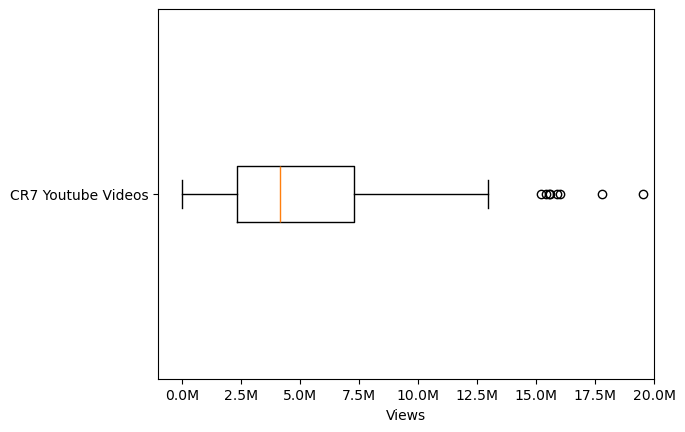

In [162]:
plt.boxplot([df_copy4['viewCount']], tick_labels= ['CR7 Youtube Videos'], vert= False)
plt.xlim(-1000000, 20000000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M'))
plt.xlabel('Views')